# Before Notebook 2 — What is a Community?
**YTS+ DSEB 2026 · Project A · Harry Potter**

---

Notebook 2 will ask you to run a community detection algorithm on the Harry Potter network.

Before you do that, you need to understand two things:
1. What a **community** actually is in a graph
2. What the algorithm **returns** — and how to read it

This notebook builds that understanding on a tiny toy network before you touch the real data.

---
## Setup

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)
DATA = 'data/'
print('Ready.')

Ready.


---
## Part 1 — What is a community?

A community is a group of nodes that are **densely connected to each other** and **sparsely connected to everyone else**.

Look at this network of 6 people. Some know each other well — they meet often (high edge weight). One pair barely knows each other (low edge weight).

**Before running anything — which two groups do you expect?**

*Write here:*

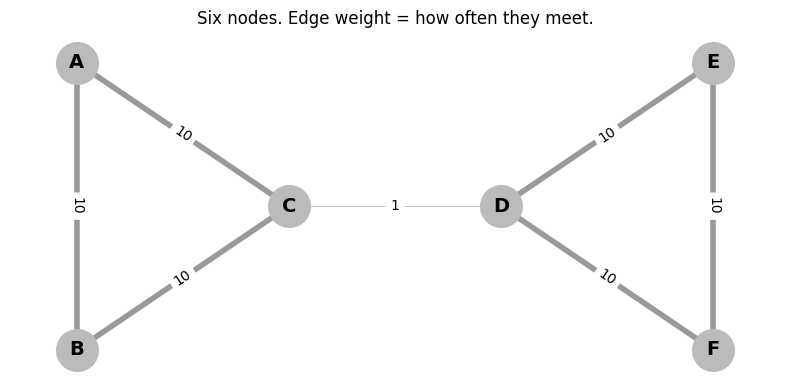

In [2]:
# Six people. Two tight groups with one weak link between them.
edges = [
    ('A', 'B', 10), ('B', 'C', 10), ('A', 'C', 10),   # left cluster
    ('D', 'E', 10), ('E', 'F', 10), ('D', 'F', 10),   # right cluster
    ('C', 'D',  1),                                    # weak bridge
]

G = nx.Graph()
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

pos = {'A': (0,1), 'B': (0,0), 'C': (1,0.5),
       'D': (2,0.5), 'E': (3,1), 'F': (3,0)}

fig, ax = plt.subplots(figsize=(8, 4))

edge_widths = [G[u][v]['weight'] * 0.4 for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#bbbbbb', node_size=900)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=14, font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, alpha=0.6, edge_color='#555')

labels = {(u, v): w for u, v, w in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, ax=ax, font_size=10)

ax.set_title('Six nodes. Edge weight = how often they meet.', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Part 2 — What Louvain returns

Louvain community detection reads only the edge weights. It finds the partition of nodes into groups that maximises **within-group density** relative to what random chance would produce.

It returns a **dictionary**: every node gets a community ID (just a number — 0, 1, 2...).

**The algorithm does not name the communities.** That is your job.

In [3]:
communities = nx.community.louvain_communities(G, weight='weight', seed=42)

# Convert to node -> community_id dict (same format as before)
partition = {node: cid for cid, comm in enumerate(communities) for node in comm}

print('What Louvain returns — a dictionary:')
print(partition)
print()
print('Community 0 members:', [n for n, c in partition.items() if c == 0])
print('Community 1 members:', [n for n, c in partition.items() if c == 1])

What Louvain returns — a dictionary:
{'B': 0, 'A': 0, 'C': 0, 'E': 1, 'D': 1, 'F': 1}

Community 0 members: ['B', 'A', 'C']
Community 1 members: ['E', 'D', 'F']


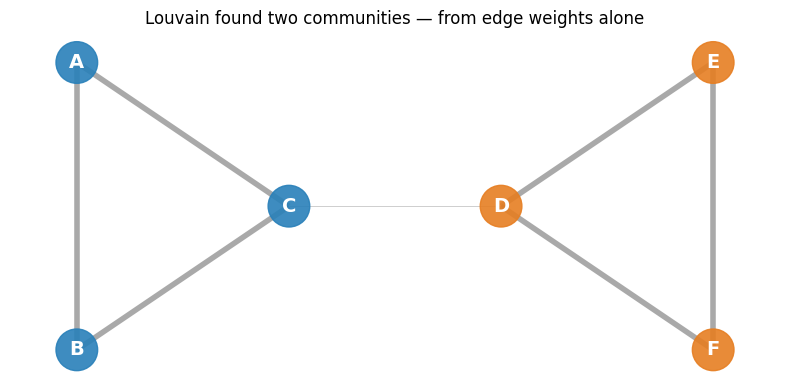

In [4]:
# Draw the same network — now coloured by community
colors = ['#2980b9' if partition[n] == 0 else '#e67e22' for n in G.nodes()]

fig, ax = plt.subplots(figsize=(8, 4))
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=900, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=14, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, alpha=0.5, edge_color='#555')

ax.set_title('Louvain found two communities — from edge weights alone', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

**Three things to notice:**

1. The algorithm never saw the node labels — just the numbers on the edges.
2. It found exactly the two groups your intuition predicted.
3. The weak edge C–D (weight 1) was not enough to merge the two groups.

Now imagine 89 characters, hundreds of edges, and weights up to 5,000. Your intuition cannot find the communities. The algorithm can.

---
## Part 3 — Reading the pre-computed data

For the Harry Potter network, we pre-ran Louvain on Books 3, 5, and 7 — both with Harry and with Harry removed. The results are in `community_analysis.csv`.

**Before you read it: understand every column.** One confusing column will break the rest of the notebook.

In [5]:
ca = pd.read_csv(DATA + 'community_analysis.csv')
print('Columns:', ca.columns.tolist())
print()
print('One row — Ron Weasley, Book 3:')
ca[(ca['character'] == 'Ronald Weasley') & (ca['book'] == 3)]

Columns: ['book', 'character', 'global_degree', 'community_with_harry', 'community_size_with_harry', 'within_degree_with_harry', 'community_without_harry', 'community_size_without_harry', 'within_degree_without_harry']

One row — Ron Weasley, Book 3:


,book,character,global_degree,community_with_harry,community_size_with_harry,within_degree_with_harry,community_without_harry,community_size_without_harry,within_degree_without_harry
0,3,Ronald Weasley,3340,0,26,2466,0,16,1283


**What every column means — using Ron as the example:**

| Column | Value | Meaning |
|---|---|---|
| `global_degree` | 3340 | Ron's total weighted degree in the Book 3 network — sum of all his edge weights, across every character |
| `community_with_harry` | 0 | Louvain assigned Ron to community 0 when Harry is in the graph |
| `community_size_with_harry` | 26 | Community 0 contains 26 characters total |
| `within_degree_with_harry` | 2466 | Sum of Ron's edge weights **only to the 25 other characters in community 0** |
| `community_without_harry` | 0 | Still community 0 after Harry removed |
| `community_size_without_harry` | 16 | Community shrank — 10 characters lost when Harry removed |
| `within_degree_without_harry` | 1283 | Ron's within-community weight dropped by half — Harry's contribution is gone |

**The key gap:** `global_degree` (3340) minus `within_degree_with_harry` (2466) = 874. That 874 is Ron's edge weight to characters in *other* communities — people he appears with but not enough to share a world.

**The Harry effect:** `within_degree` dropped from 2466 to 1283 when Harry was removed. Roughly half of Ron's scene-weight within the trio world was in scenes that also contained Harry.

In [6]:
# Ron's community WITH Harry — who is in it?
b3 = ca[ca['book'] == 3]
ron_comm = b3[b3['character'] == 'Ronald Weasley']['community_with_harry'].values[0]

with_harry = (
    b3[b3['community_with_harry'] == ron_comm]
    .sort_values('within_degree_with_harry', ascending=False)
    [['character', 'within_degree_with_harry']]
    .reset_index(drop=True)
)
with_harry.index += 1

print(f"Ron's community (Book 3, WITH Harry) — {len(with_harry)} characters:")
print(with_harry.head(10).to_string())

Ron's community (Book 3, WITH Harry) — 25 characters:
           character  within_degree_with_harry
1   Hermione Granger                      2477
2     Ronald Weasley                      2466
3      Rubeus Hagrid                       643
4           Buckbeak                       238
5   Sybill Trelawney                       231
6        Crookshanks                       175
7     Vernon Dursley                       144
8             Hedwig                        84
9    Petunia Dursley                        70
10    Dudley Dursley                        64


In [7]:
# Same community WITHOUT Harry — who remains, and what changed?
ron_comm_no = b3[b3['character'] == 'Ronald Weasley']['community_without_harry'].values[0]

without_harry = (
    b3[b3['community_without_harry'] == ron_comm_no]
    .sort_values('within_degree_without_harry', ascending=False)
    [['character', 'within_degree_without_harry']]
    .reset_index(drop=True)
)
without_harry.index += 1

print(f"Ron's community (Book 3, WITHOUT Harry) — {len(without_harry)} characters:")
print(without_harry.head(10).to_string())
print()
print(f'Community shrank from 26 to {len(without_harry)} characters.')
print(f'Hermione within-degree: 2477 (with Harry) → {without_harry[without_harry["character"]=="Hermione Granger"]["within_degree_without_harry"].values[0]} (without)')

Ron's community (Book 3, WITHOUT Harry) — 16 characters:
           character  within_degree_without_harry
1   Hermione Granger                         1313
2     Ronald Weasley                         1283
3      Rubeus Hagrid                          390
4           Buckbeak                          123
5   Sybill Trelawney                          110
6        Crookshanks                           98
7              Errol                           47
8   Father Christmas                           28
9             Hedwig                           27
10   Filius Flitwick                           19

Community shrank from 26 to 16 characters.
Hermione within-degree: 2477 (with Harry) → 1313 (without)


---
## You are ready for Notebook 2

You now know:
- A community = dense inside, sparse between. The algorithm finds it from edge weights alone.
- Louvain returns a dictionary — node to community ID. You name the communities.
- `within_degree` is not the same as `global_degree` — it counts only edges inside the same community.
- Removing Harry shrinks communities and drops within-degree — because his scenes were mediating many connections.

**Open `nb2_communities.ipynb`.**